# CNN for MNIST Digits Classification With Tensorflow 2.x

In this tutorial we build a deep-learning based CNN model for digits classification.

## Packages and dataset

First, we import the required packages:

In [10]:
# importing the required packages
from numpy import unique, argmax
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import plot_model
from matplotlib import pyplot
import matplotlib.pyplot as plt
import numpy as np

Next, we load a dataset of hand-written digits (MNIST dataset) and split it into a training and a test set.

In [11]:
# loading the MNIST dataset
(x_train, y_train), (x_test, y_test) = load_data()
# reshaping the training and testing data 
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1],
x_train.shape[2], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], x_test.shape[2], 1))

Pixel values should be floating-point values from 0.0 to 1.0:

In [12]:
# normalizing the values of pixels of images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

Let's plot some of the hand-written digits along with their labels:

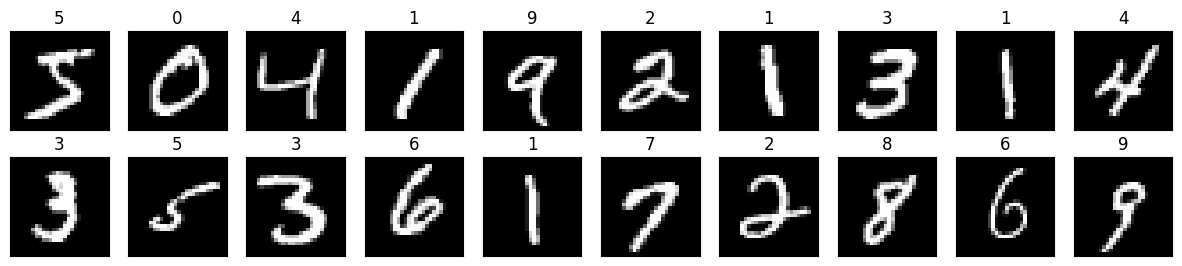

In [13]:
fig = plt.figure(figsize=(15,3))
for i in range(20):
 ax = fig.add_subplot(2,10, i+1, xticks=[], yticks=[])
 ax.imshow(np.squeeze(x_train[i]), cmap='gray')
 ax.set_title(y_train[i])

In [14]:
# determine the shape of the input images
inp_shape = x_train.shape[1:]
print(inp_shape)

(28, 28, 1)


## Building the neural network

It is time to define our (deep) neural network. We use 8 layers of different types:

In [15]:
# defining the model
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=inp_shape))
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(48, (3,3), activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(500, activation='relu'))
model.add(Dense(10, activation='softmax'))
# text Description of model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │       600,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,702 (2.36 MB)

 Trainable params: 619,702 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

## Train the network

We can now train our model. In general, the quality of the network increases with the number of training epochs and batch size.

In [16]:
# define loss and optimizer
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# fit the model
history = model.fit(x_train, y_train, epochs=10, batch_size=128, verbose=2, validation_split=0.1)

Epoch 1/10
422/422 - 4s - 10ms/step - accuracy: 0.9241 - loss: 0.2468 - val_accuracy: 0.9823 - val_loss: 0.0610
Epoch 2/10
422/422 - 3s - 8ms/step - accuracy: 0.9752 - loss: 0.0821 - val_accuracy: 0.9885 - val_loss: 0.0402
Epoch 3/10
422/422 - 3s - 8ms/step - accuracy: 0.9810 - loss: 0.0598 - val_accuracy: 0.9905 - val_loss: 0.0358
Epoch 4/10
422/422 - 3s - 8ms/step - accuracy: 0.9846 - loss: 0.0488 - val_accuracy: 0.9917 - val_loss: 0.0321
Epoch 5/10
422/422 - 3s - 8ms/step - accuracy: 0.9861 - loss: 0.0416 - val_accuracy: 0.9903 - val_loss: 0.0353
Epoch 6/10
422/422 - 3s - 8ms/step - accuracy: 0.9881 - loss: 0.0373 - val_accuracy: 0.9928 - val_loss: 0.0270
Epoch 7/10
422/422 - 3s - 8ms/step - accuracy: 0.9894 - loss: 0.0328 - val_accuracy: 0.9915 - val_loss: 0.0265
Epoch 8/10
422/422 - 3s - 8ms/step - accuracy: 0.9902 - loss: 0.0296 - val_accuracy: 0.9913 - val_loss: 0.0272
Epoch 9/10
422/422 - 3s - 8ms/step - accuracy: 0.9905 - loss: 0.0278 - val_accuracy: 0.9933 - val_loss: 0.0262


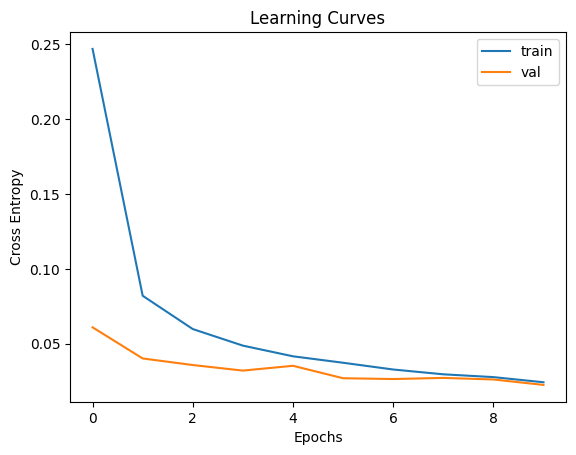

In [17]:
# ploting the learning curves
pyplot.title('Learning Curves')
pyplot.xlabel('Epochs')
pyplot.ylabel('Cross Entropy')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()

## Evaluate the network

We now evaluate our model on previously unseen images:

In [21]:
# evaluate the model
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Accuracy: {accuracy*100}')

Accuracy: 99.36000108718872


Finally, we can use our network for image classification. In the following code block, assign different numbers to image_idx to classify different images:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted: 4  Correct: 4


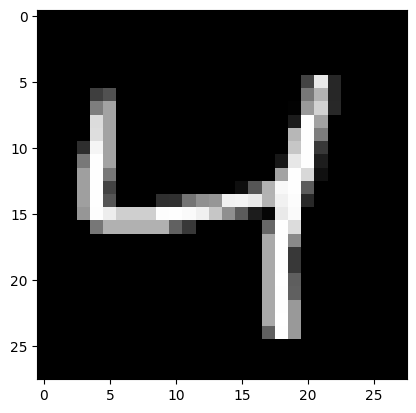

In [22]:
image_idx = 2
image = x_train[image_idx]
# lets display the image which we want to predict
plt.imshow(np.squeeze(image), cmap='gray')
# make a prediction
# reshaping the image for model input
image = image.reshape(1, image.shape[0], image.shape[1], image.shape[2])
# predicting the label of image
yhat = model.predict([image])
print('Predicted: {}'.format(argmax(yhat)), ' Correct: {}'.format(y_train[image_idx]))

### Exercise 4.4: Use the CNN from above and try to find a training sample that is *incorrectly* classified. You may also retrain the network with a lower of epochs to decrease the quality in order to make this task easier.